In [118]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [119]:
#Allow the user to insert the values of the simulation

alpha = float(input("alpha: "))
beta = float(input("beta: "))
gamma = float(input("gamma: "))
delta = float(input("delta: "))
R0 =  float(input("R(t=0): "))
F0 =  float(input("F(t=0): "))
T = float(input('Time [s]: '))
dt = float(input('dt [s]: '))


# Prepare func
def odes(u, t):
    """This function represents the first order ODEs to be integrated
    It returns the tuple (dR/dt, dF/dt), given u=(R,F) and t."""
    R, F = u
    return (alpha*R-beta*R*F, -gamma*F+delta*R*F)

# Prepare t, the sampling times
t = np.arange(0, T, dt)

#The initial conditions R(t=0) and F(t=0)
u0 = np.array([R0,F0])

# Solve the ODEs
u = odeint(odes, u0, t)


In [120]:
#I save the values in a file
name = "values.dat"
with open(name, 'w') as f:
    [f.write(str(u[i,0]) + '\t' + str(u[i,0]) + '\n') for i in range(len(u))]

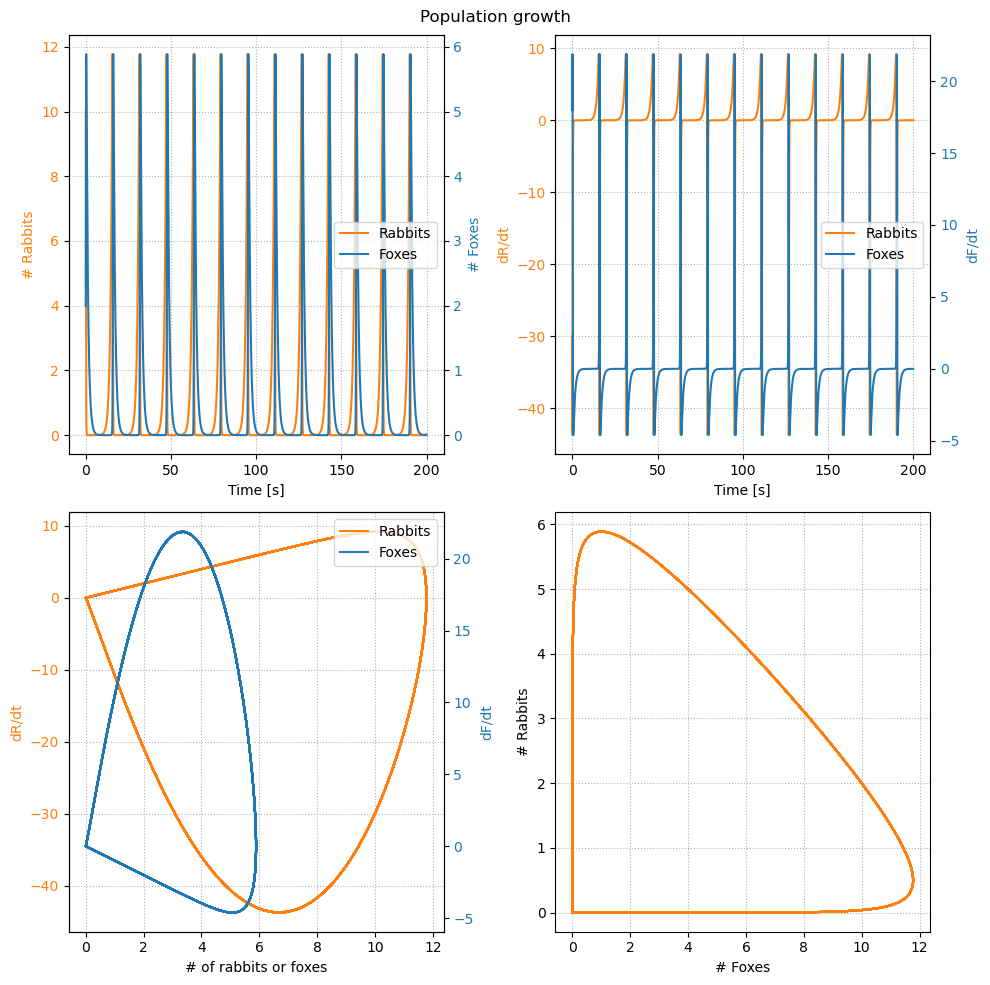

In [121]:
# Plot x and v vs t using matplotlib so that they use distinct vertical axes
R = u[:,0]
F = u[:,1]
dR, dF= alpha*R-beta*R*F, -gamma*F+delta*R*F


fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(221)
fig.suptitle('Population growth')
ax1.set_xlabel('Time [s]')

color = 'tab:orange'
ax1.set_ylabel('# Rabbits', color=color)
line1 = ax1.plot(t, R, label='Rabbits', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(ls=':')

# The second Axes object shares the x-axis with the first Axes object
ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('# Foxes', color=color)  # we already handled the x-label with ax1
line2 = ax2.plot(t, F, label='Foxes', color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc=0)



#I plot dR/dt and dF/dt vs t
ax3 = fig.add_subplot(222)
fig.suptitle('Population growth')
ax3.set_xlabel('Time [s]')

color = 'tab:orange'
ax3.set_ylabel('dR/dt', color=color)
line1 = ax3.plot(t, dR, label='Rabbits', color=color)
ax3.tick_params(axis='y', labelcolor=color)
ax3.grid(ls=':')

# The second Axes object shares the x-axis with the first Axes object
ax4 = ax3.twinx()

color = 'tab:blue'
ax4.set_ylabel('dF/dt', color=color)  # we already handled the x-label with ax1
line2 = ax4.plot(t, dF, label='Foxes', color=color)
ax4.tick_params(axis='y', labelcolor=color)

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc=0)



#I plot dR/dt vs R and dF/dt vs F
ax5 = fig.add_subplot(223)
fig.suptitle('Population growth')
ax5.set_xlabel('# of rabbits or foxes')

color = 'tab:orange'
ax5.set_ylabel('dR/dt', color=color)
line1 = ax5.plot(R, dR, label='Rabbits', color=color)
ax5.tick_params(axis='y', labelcolor=color)
ax5.grid(ls=':')

# The second Axes object shares the x-axis with the first Axes object
ax6 = ax5.twinx()

color = 'tab:blue'
ax6.set_ylabel('dF/dt', color=color)  # we already handled the x-label with ax1
line2 = ax6.plot(F, dF, label='Foxes', color=color)
ax6.tick_params(axis='y', labelcolor=color)

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax6.legend(lines, labels, loc=0)

#I plot dR/dt vs R and dF/dt vs F
ax7 = fig.add_subplot(224)
fig.suptitle('Population growth')
ax7.set_xlabel('# Foxes')

color = 'tab:orange'
ax7.set_ylabel('# Rabbits')
line1 = ax7.plot(R, F, label='Rabbits', color=color)
ax7.grid(ls=':')

# Avoid clipping of the right hand side y-label
fig.tight_layout()
plt.show()

In [134]:
#Initial conditions for different simulations
alpha = [1, 3, 4, 4, 5]
beta = [2, 3, 5, 1, 5]
gamma = [1, 5, 10, 2, 3]
delta = [2, 5, 4, 1, 1]
R0 =  [10, 20, 30, 40 ,50]
F0 =  [1, 2, 3, 20, 5]

T = 20
dt = 0.01
# Prepare t, the sampling times
t = np.arange(0, T, dt)
u_tot = [] #array with all the values for each simulation

# Prepare func
def odes(u, t, i):
    """This function represents the first order ODEs to be integrated
    It returns the tuple (dR/dt, dF/dt), given u=(R,F) and t."""
    R, F = u
    return (alpha[i]*R-beta[i]*R*F, -gamma[i]*F+delta[i]*R*F)


for i in range(5):
#The initial conditions R(t=0) and F(t=0)
    u0 = np.array([R0[i],F0[i]])
    # Solve the ODEs
    u = odeint(odes, u0, t, args=tuple([i]))
    u_tot.append(u)
u_tot = np.array(u_tot)

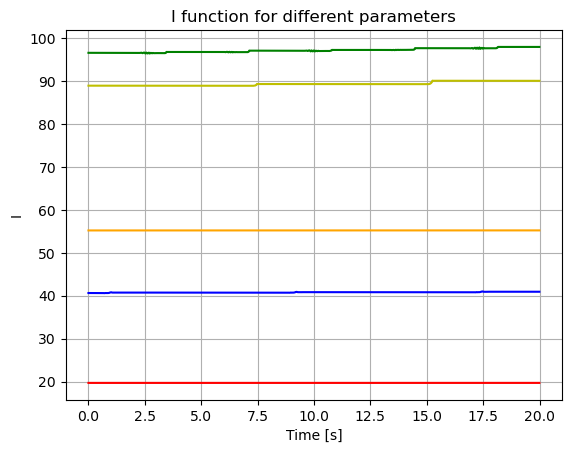

In [ ]:
I_tot = []
for i in range(5): #I create the function I
    R=u_tot[i, :, 0]
    F=u_tot[i, :, 1]
    I = delta[i]*R - gamma[i]*np.log(R) + beta[i]*F - alpha[i]*np.log(F)
    I_tot.append(I)
I_tot = np.array(I_tot) #Function I for all the different parameters

#plot I
plt.title('I function for different parameters')
plt.xlabel('Time [s]')
plt.ylabel('I')

for i in range(5):
    color = ['r', 'y', 'g', 'b', 'orange']
    line1 = plt.plot(t, I_tot[i], color=color[i])
plt.grid()

In [126]:
#Initial conditions for different simulations
alpha = 1
beta = 1
gamma = 2
delta = 1
R0 =  np.arange(2, 21, 2)
F0 =  2

T = 200
dt = 0.01
# Prepare t, the sampling times
t = np.arange(0, T, dt)
u_tot = [] #array with all the values for each simulation

# Prepare func
def odes(u, t):
    """This function represents the first order ODEs to be integrated
    It returns the tuple (dR/dt, dF/dt), given u=(R,F) and t."""
    R, F = u
    return (alpha*R-beta*R*F, -gamma*F+delta*R*F)


for i in range(len(R0)):
#The initial conditions R(t=0) and F(t=0)
    u0 = np.array([R0[i],F0])
    # Solve the ODEs
    u = odeint(odes, u0, t)
    u_tot.append(u)
u_tot = np.array(u_tot)

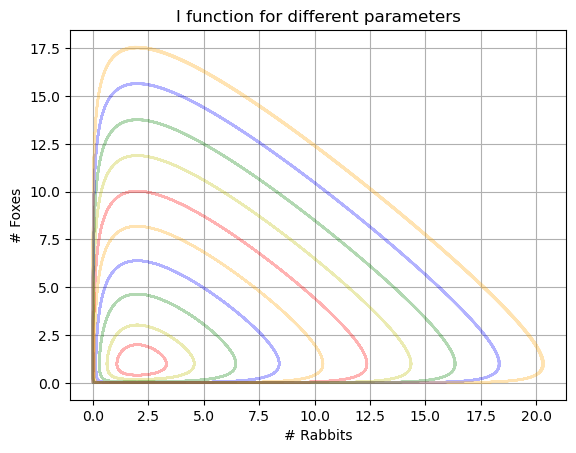

In [128]:
#plot the different initial conditions
plt.title('I function for different parameters')
plt.xlabel('# Rabbits')
plt.ylabel('# Foxes')

for i in range(len(R0)):
    color = ['r', 'y', 'g', 'b', 'orange']
    plt.plot(u_tot[i, :, 0], u_tot[i, :, 1], label='Rabbits vs Foxes', color=color[i%5], alpha=0.3)
plt.grid()